In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Geospatial Source-Attribution Engine — Complete Pipeline

This notebook completes the source-attribution pipeline using the data you already extracted.

## Final pipeline

```text
future_aqi_forecast.csv
        +
OSM parquet layers
        |
        v
Static per-cell geospatial features
        |
        +--------------------+
        |                    |
        v                    v
Local source evidence    Wind / upwind evidence
        |                    |
        +----------+---------+
                   |
                   v
       Traffic / Industry / Construction
              evidence scores
                   |
                   v
      Dominant source + confidence
                   |
                   v
        source_attribution.csv
```

The notebook intentionally uses **evidence-based directional attribution**, not a full atmospheric plume model.
It combines:

1. local road, industrial and construction evidence;
2. proximity to candidate sources;
3. wind direction and wind speed;
4. an upwind search corridor;
5. AQI hotspot severity;
6. optional SHAP-based spatial explanation as a secondary diagnostic.

The primary attribution result is therefore based on explicit geospatial and wind evidence rather than training a model to explain its own AQI forecasts.

## 0. Environment

Run once in the project virtual environment:

```bash
pip install pandas numpy geopandas shapely pyarrow scikit-learn xgboost shap matplotlib joblib
```

`pyrosm` is only required if the existing parquet layers must be regenerated.

In [ ]:
import os
import json
import math
import logging
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString
from shapely.ops import unary_union

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
pd.set_option("display.max_columns", 200)

print("Environment ready")

Environment ready


## 1. Configuration

Change only `BASE` if the project is moved.

Important: use the **same bounding box and cell IDs as the forecasting pipeline**. The notebook does not need to
re-extract OSM data when the parquet files already exist.

In [ ]:
BASE = "drive/MyDrive/ET_Hackathon"

@dataclass
class Paths:
    PBF_PATH: str = f"{BASE}/india-latest.osm.pbf"
    OSM_DIR: str = f"{BASE}/data/osm_layers"
    FORECAST_CSV: str = f"{BASE}/data/future_aqi_forecast.csv"
    TRAINING_DATASET: str = f"{BASE}/data/training_dataset.csv"
    FORECAST_WEATHER: str = f"{BASE}/data/forecast_weather.csv"

    OSM_FEATURES_CSV: str = f"{BASE}/data/osm_features.csv"
    SOURCE_EVIDENCE_CSV: str = f"{BASE}/data/source_evidence.csv"
    ATTRIBUTION_CSV: str = f"{BASE}/data/source_attribution.csv"
    ATTRIBUTION_GEOJSON: str = f"{BASE}/data/source_attribution.geojson"

P = Paths()

LATLON_CRS = "EPSG:4326"
PROJECTED_CRS = "EPSG:32643"       # Delhi, units = metres

CELL_BUFFER_M = 500                # 1 km x 1 km local evidence cell
UPWIND_LENGTH_M = 5000             # search up to 5 km upwind
UPWIND_HALF_WIDTH_M = 600          # corridor width = 1.2 km
MIN_WIND_SPEED = 0.5               # m/s; below this direction is weak evidence

# Match this to the forecasting grid if Stage 1 is ever re-run.
BBOX = (76.80, 28.40, 77.40, 28.90)

os.makedirs(f"{BASE}/data", exist_ok=True)

print("BASE:", BASE)
print("OSM directory:", P.OSM_DIR)

BASE: drive/MyDrive/ET_Hackathon
OSM directory: drive/MyDrive/ET_Hackathon/data/osm_layers


## 2. Validate inputs and inspect the actual forecast schema

This catches the most common integration problems before expensive GIS work begins.

In [ ]:
REQUIRED_LAYERS = [
    "roads.parquet",
    "road_nodes.parquet",
    "buildings.parquet",
    "industrial.parquet",
    "construction.parquet",
    "green.parquet",
    "water.parquet",
]

missing_files = [
    name for name in REQUIRED_LAYERS
    if not os.path.exists(os.path.join(P.OSM_DIR, name))
]

if missing_files:
    raise FileNotFoundError(
        "Missing OSM layers: " + ", ".join(missing_files)
    )

if not os.path.exists(P.FORECAST_CSV):
    raise FileNotFoundError(P.FORECAST_CSV)

forecast = pd.read_csv(P.FORECAST_CSV)

# Normalize common alternative column names.
rename_map = {}
if "latitude" in forecast.columns and "lat" not in forecast.columns:
    rename_map["latitude"] = "lat"
if "longitude" in forecast.columns and "lon" not in forecast.columns:
    rename_map["longitude"] = "lon"
if "predicted_aqi" in forecast.columns and "forecast_aqi" not in forecast.columns:
    rename_map["predicted_aqi"] = "forecast_aqi"
forecast = forecast.rename(columns=rename_map)

required_forecast_cols = {"cell_id", "lat", "lon", "forecast_aqi"}
missing = required_forecast_cols - set(forecast.columns)
if missing:
    raise ValueError(f"Forecast CSV is missing required columns: {sorted(missing)}")

if "horizon_hours" not in forecast.columns:
    forecast["horizon_hours"] = np.nan

print("Forecast rows:", len(forecast))
print("Unique cells:", forecast["cell_id"].nunique())
print("Horizons:", sorted(forecast["horizon_hours"].dropna().unique().tolist()))
print("Columns:")
print(forecast.columns.tolist())
display(forecast.head())

Forecast rows: 4800
Unique cells: 1600
Horizons: [24, 48, 72]
Columns:
['cell_id', 'lat', 'lon', 'is_estimated', 'nearest_station', 'nearest_dist_km', 'source_timestamp', 'target_timestamp', 'horizon_hours', 'forecast_aqi', 'source_aqi']


,cell_id,lat,lon,is_estimated,nearest_station,nearest_dist_km,source_timestamp,target_timestamp,horizon_hours,forecast_aqi,source_aqi
0,0,28.4,76.800000,1,"Vikas Sadan, Gurugram - HSPCB",22.821,2026-07-12 17:00:00,2026-07-13 17:00:00,24,60.8,46.798035
1,1,28.4,76.815385,1,"Vikas Sadan, Gurugram - HSPCB",21.366,2026-07-12 17:00:00,2026-07-13 17:00:00,24,60.8,46.798035
2,2,28.4,76.830769,1,"Vikas Sadan, Gurugram - HSPCB",19.917,2026-07-12 17:00:00,2026-07-13 17:00:00,24,60.8,46.798035
3,3,28.4,76.846154,1,"Vikas Sadan, Gurugram - HSPCB",18.477,2026-07-12 17:00:00,2026-07-13 17:00:00,24,60.8,46.798035
4,4,28.4,76.861538,1,"Vikas Sadan, Gurugram - HSPCB",17.049,2026-07-12 17:00:00,2026-07-13 17:00:00,24,60.8,46.798035


## 3. Load and clean OSM layers

All geometry calculations are performed in UTM 43N so that distance and area are measured in metres.
Invalid geometries are repaired where possible.

In [ ]:
def load_layer(name):
    path = os.path.join(P.OSM_DIR, name)
    gdf = gpd.read_parquet(path)

    if gdf.crs is None:
        gdf = gdf.set_crs(LATLON_CRS)

    gdf = gdf[gdf.geometry.notna()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()

    try:
        gdf["geometry"] = gdf.geometry.make_valid()
    except Exception:
        gdf["geometry"] = gdf.geometry.buffer(0)

    return gdf.to_crs(PROJECTED_CRS)


def recover_osm_tag_column(gdf, column):
    """
    Recover an OSM attribute such as 'highway' from the tags column
    when pyrosm stored it inside a dictionary instead of a standalone column.
    """
    if column in gdf.columns:
        return gdf

    if "tags" not in gdf.columns:
        return gdf

    def extract_tag(tags):
        if isinstance(tags, dict):
            return tags.get(column)

        # Some parquet files may deserialize dictionaries as strings.
        if isinstance(tags, str):
            try:
                import ast
                parsed = ast.literal_eval(tags)

                if isinstance(parsed, dict):
                    return parsed.get(column)
            except Exception:
                return None

        return None

    gdf[column] = gdf["tags"].apply(extract_tag)

    return gdf


roads = load_layer("roads.parquet")

# Try recovering highway from OSM tags.
roads = recover_osm_tag_column(roads, "highway")
roads = recover_osm_tag_column(roads, "name")
roads = recover_osm_tag_column(roads, "lanes")
roads = recover_osm_tag_column(roads, "maxspeed")

road_nodes = load_layer("road_nodes.parquet")
buildings = load_layer("buildings.parquet")
industrial = load_layer("industrial.parquet")
construction = load_layer("construction.parquet")
green = load_layer("green.parquet")
water = load_layer("water.parquet")


print("\\nROAD COLUMNS:")
print(roads.columns.tolist())

if "highway" in roads.columns:
    print("\\nHighway values:")
    print(roads["highway"].value_counts(dropna=False).head(30))

    print(
        "\\nRows with valid highway classification:",
        roads["highway"].notna().sum(),
        "/",
        len(roads)
    )

else:
    raise ValueError(
        "roads.parquet does not contain a 'highway' column "
        "and it could not be recovered from 'tags'. "
        "The road layer must be re-extracted from the PBF."
    )

\nROAD COLUMNS:
['id', 'highway', 'name', 'lanes', 'maxspeed', 'geometry']
\nHighway values:
highway
residential       795705
service           208811
tertiary           94578
secondary          40514
unclassified       26576
living_street      20791
primary            11832
trunk              10419
secondary_link      6113
trunk_link          4285
motorway            3428
primary_link        2942
tertiary_link       2039
motorway_link       2028
busway                59
bus_stop              51
services              19
rest_area             11
road                   7
crossing               2
Name: count, dtype: int64
\nRows with valid highway classification: 1230210 / 1230210


## 4. Build unique 1 km grid-cell geometries

The forecast file normally contains one row per `(cell_id, horizon)`. Static OSM features are calculated only once
per unique cell and later merged back to all forecast horizons.

In [ ]:
unique_cells_df = (
    forecast[["cell_id", "lat", "lon"]]
    .drop_duplicates("cell_id")
    .reset_index(drop=True)
)

cell_points = gpd.GeoDataFrame(
    unique_cells_df.copy(),
    geometry=gpd.points_from_xy(unique_cells_df["lon"], unique_cells_df["lat"]),
    crs=LATLON_CRS,
).to_crs(PROJECTED_CRS)

cells = cell_points.copy()
cells["point_geometry"] = cells.geometry
cells["geometry"] = cells.geometry.buffer(CELL_BUFFER_M, cap_style=3)
cells["cell_area_sqm"] = cells.geometry.area

print("Unique GIS cells:", len(cells))
display(cells[["cell_id", "lat", "lon", "cell_area_sqm"]].head())

Unique GIS cells: 1600


,cell_id,lat,lon,cell_area_sqm
0,0,28.4,76.800000,1000000.0
1,1,28.4,76.815385,1000000.0
2,2,28.4,76.830769,1000000.0
3,3,28.4,76.846154,1000000.0
4,4,28.4,76.861538,1000000.0


## 5. Static local source features

These features answer: **what potential sources exist inside or close to this 1 km cell?**

Traffic evidence:
- road length by class;
- weighted road load;
- road density;
- intersections;
- distance to major roads.

Industrial and construction evidence:
- area coverage;
- polygon count;
- nearest-source distance.

Green and water are retained as contextual/mitigating features.

In [ ]:
def safe_sjoin(left, right, predicate="intersects"):
    if left.empty or right.empty:
        return gpd.GeoDataFrame()
    return gpd.sjoin(left, right, how="inner", predicate=predicate)


def clipped_line_length_features(cells_gdf, roads_gdf):
    out = pd.DataFrame(index=cells_gdf.index)

    road_classes = ["motorway", "trunk", "primary", "secondary", "tertiary", "residential"]
    for rc in road_classes:
        out[f"{rc}_length"] = 0.0

    if not roads_gdf.empty:
        joined = safe_sjoin(roads_gdf, cells_gdf[["geometry"]])
        if not joined.empty:
            joined = joined.copy()
            cell_geoms = cells_gdf.geometry.reindex(joined["index_right"]).values
            joined["clipped"] = [
                geom.intersection(cell_geom)
                for geom, cell_geom in zip(joined.geometry, cell_geoms)
            ]
            joined["length_m"] = gpd.GeoSeries(joined["clipped"], crs=PROJECTED_CRS).length.values

            for rc in road_classes:
                vals = (
                    joined.loc[joined["highway"].astype(str) == rc]
                    .groupby("index_right")["length_m"].sum()
                )
                out[f"{rc}_length"] = vals.reindex(cells_gdf.index, fill_value=0.0)

    out["total_road_length"] = out[[f"{r}_length" for r in road_classes]].sum(axis=1)
    out["road_density"] = out["total_road_length"] / cells_gdf["cell_area_sqm"]

    # Emission-oriented proxy: major roads count more than residential roads.
    weights = {
        "motorway": 1.00,
        "trunk": 0.90,
        "primary": 0.75,
        "secondary": 0.55,
        "tertiary": 0.35,
        "residential": 0.15,
    }
    out["weighted_road_load"] = sum(
        out[f"{rc}_length"] * weight for rc, weight in weights.items()
    )

    major = roads_gdf[
        roads_gdf.get("highway", pd.Series(index=roads_gdf.index, dtype=object))
        .astype(str).isin(["motorway", "trunk", "primary"])
    ].copy()

    centroids = cells_gdf.copy()
    centroids["geometry"] = centroids["point_geometry"]

    if not major.empty:
        near = gpd.sjoin_nearest(
            centroids[["geometry"]],
            major[["geometry"]],
            how="left",
            distance_col="distance_to_nearest_major_road",
        )
        near = near[~near.index.duplicated(keep="first")]
        out["distance_to_nearest_major_road"] = (
            near["distance_to_nearest_major_road"]
            .reindex(cells_gdf.index)
        )
    else:
        out["distance_to_nearest_major_road"] = np.nan

    nodes_joined = safe_sjoin(road_nodes, cells_gdf[["geometry"]])
    counts = (
        nodes_joined.groupby("index_right").size()
        if not nodes_joined.empty else pd.Series(dtype=float)
    )
    out["intersection_count"] = counts.reindex(cells_gdf.index, fill_value=0)
    out["intersection_density"] = out["intersection_count"] / cells_gdf["cell_area_sqm"]

    return out


def polygon_features(cells_gdf, layer, prefix, calc_distance=True):
    out = pd.DataFrame(index=cells_gdf.index)
    out[f"{prefix}_area"] = 0.0
    out[f"{prefix}_polygon_count"] = 0
    out[f"{prefix}_percentage"] = 0.0

    joined = safe_sjoin(layer, cells_gdf[["geometry"]])
    if not joined.empty:
        joined = joined.copy()
        cell_geoms = cells_gdf.geometry.reindex(joined["index_right"]).values
        joined["clipped"] = [
            geom.intersection(cell_geom)
            for geom, cell_geom in zip(joined.geometry, cell_geoms)
        ]
        joined["clipped_area"] = gpd.GeoSeries(
            joined["clipped"], crs=PROJECTED_CRS
        ).area.values

        area = joined.groupby("index_right")["clipped_area"].sum()
        count = joined.groupby("index_right").size()

        out[f"{prefix}_area"] = area.reindex(cells_gdf.index, fill_value=0.0)
        out[f"{prefix}_polygon_count"] = count.reindex(cells_gdf.index, fill_value=0)
        out[f"{prefix}_percentage"] = (
            out[f"{prefix}_area"] / cells_gdf["cell_area_sqm"] * 100
        ).clip(0, 100)

    if calc_distance:
        centroids = cells_gdf.copy()
        centroids["geometry"] = centroids["point_geometry"]

        if not layer.empty:
            near = gpd.sjoin_nearest(
                centroids[["geometry"]],
                layer[["geometry"]],
                how="left",
                distance_col="distance",
            )
            near = near[~near.index.duplicated(keep="first")]
            out[f"distance_to_nearest_{prefix}"] = (
                near["distance"].reindex(cells_gdf.index)
            )
        else:
            out[f"distance_to_nearest_{prefix}"] = np.nan

    return out


road_f = clipped_line_length_features(cells, roads)
building_f = polygon_features(cells, buildings, "building", calc_distance=False)
industrial_f = polygon_features(cells, industrial, "industrial", calc_distance=True)
construction_f = polygon_features(cells, construction, "construction", calc_distance=True)
green_f = polygon_features(cells, green, "green", calc_distance=False)
water_f = polygon_features(cells, water, "water", calc_distance=True)

static_features = pd.concat(
    [road_f, building_f, industrial_f, construction_f, green_f, water_f],
    axis=1
)

cell_features = pd.concat(
    [cells[["cell_id", "lat", "lon"]].reset_index(drop=True),
     static_features.reset_index(drop=True)],
    axis=1
)

osm_features = forecast.merge(
    cell_features.drop(columns=["lat", "lon"]),
    on="cell_id",
    how="left"
)

osm_features.to_csv(P.OSM_FEATURES_CSV, index=False)
print("Saved:", P.OSM_FEATURES_CSV)
print("Rows:", len(osm_features))
display(osm_features.head())

Saved: drive/MyDrive/ET_Hackathon/data/osm_features.csv
Rows: 4800


,cell_id,lat,lon,is_estimated,nearest_station,nearest_dist_km,source_timestamp,target_timestamp,horizon_hours,forecast_aqi,source_aqi,motorway_length,trunk_length,primary_length,secondary_length,tertiary_length,residential_length,total_road_length,road_density,weighted_road_load,distance_to_nearest_major_road,intersection_count,intersection_density,building_area,building_polygon_count,building_percentage,industrial_area,industrial_polygon_count,industrial_percentage,distance_to_nearest_industrial,construction_area,construction_polygon_count,construction_percentage,distance_to_nearest_construction,green_area,green_polygon_count,green_percentage,water_area,water_polygon_count,water_percentage,distance_to_nearest_water
0,0,28.4,76.800000,1,"Vikas Sadan, Gurugram - HSPCB",22.821,2026-07-12 17:00:00,2026-07-13 17:00:00,24,60.8,46.798035,0.0,0.0,0.0,0.0,0.000000,949.829217,949.829217,0.000950,142.474383,6567.334067,26,0.000026,0.000000,0,0.000000,0.000000,0,0.000000,4501.295436,0.000000,0,0.000000,5407.383041,0.0,0,0.0,0.0,0,0.0,7025.255270
1,1,28.4,76.815385,1,"Vikas Sadan, Gurugram - HSPCB",21.366,2026-07-12 17:00:00,2026-07-13 17:00:00,24,60.8,46.798035,0.0,0.0,0.0,0.0,0.000000,1433.527886,1433.527886,0.001434,215.029183,5059.827199,20,0.000020,0.000000,0,0.000000,0.000000,0,0.000000,3007.788939,0.000000,0,0.000000,3899.850319,0.0,0,0.0,0.0,0,0.0,5672.219902
2,2,28.4,76.830769,1,"Vikas Sadan, Gurugram - HSPCB",19.917,2026-07-12 17:00:00,2026-07-13 17:00:00,24,60.8,46.798035,0.0,0.0,0.0,0.0,541.641162,87.750323,629.391485,0.000629,202.736955,3552.411035,5,0.000005,0.000000,0,0.000000,0.000000,0,0.000000,1542.210586,0.000000,0,0.000000,2392.408055,0.0,0,0.0,0.0,0,0.0,4409.013412
3,3,28.4,76.846154,1,"Vikas Sadan, Gurugram - HSPCB",18.477,2026-07-12 17:00:00,2026-07-13 17:00:00,24,60.8,46.798035,0.0,0.0,0.0,0.0,747.032601,2877.199770,3624.232371,0.003624,693.041376,2044.889544,182,0.000182,24733.319903,281,2.473332,81557.882982,1,8.155788,415.836996,0.000000,0,0.000000,884.860211,0.0,0,0.0,0.0,0,0.0,3348.091685
4,4,28.4,76.861538,1,"Vikas Sadan, Gurugram - HSPCB",17.049,2026-07-12 17:00:00,2026-07-13 17:00:00,24,60.8,46.798035,0.0,0.0,0.0,0.0,0.000000,1194.198942,1194.198942,0.001194,179.129841,537.458638,171,0.000171,2249.090030,20,0.224909,50387.771348,1,5.038777,458.064289,555212.430355,1,55.521243,0.000000,0.0,0,0.0,0.0,0,0.0,2739.339346


## 5B. Fetch spatial + temporal forecast wind

This stage fetches hourly forecast wind for a 3×3 grid covering the forecast domain and caches it as
`data/forecast_weather_spatial.csv`. Each AQI forecast row is then matched by nearest weather point and `target_timestamp`.
This replaces historical climatological wind in the primary attribution path.

In [ ]:
import urllib.parse, urllib.request, json, time

DATA_DIR = os.path.dirname(P.OSM_DIR)
SPATIAL_FORECAST_WEATHER = os.path.join(DATA_DIR, "forecast_weather_spatial.csv")
REFRESH_FORECAST_WEATHER = True

def fetch_weather_point(lat, lon):
    params = {
        "latitude": lat, "longitude": lon,
        "hourly": "wind_speed_10m,wind_direction_10m",
        "wind_speed_unit": "ms", "timezone": "UTC",
        "start_date": "2026-07-12",
        "end_date": "2026-07-16",
    }
    url = "https://api.open-meteo.com/v1/forecast?" + urllib.parse.urlencode(params)
    with urllib.request.urlopen(url, timeout=60) as r:
        p = json.loads(r.read().decode())
    h = p["hourly"]
    return pd.DataFrame({
        "weather_lat": float(p.get("latitude", lat)),
        "weather_lon": float(p.get("longitude", lon)),
        "weather_timestamp": pd.to_datetime(h["time"], utc=True),
        "wind_speed_forecast": pd.to_numeric(h["wind_speed_10m"], errors="coerce"),
        "wind_dir_forecast": pd.to_numeric(h["wind_direction_10m"], errors="coerce") % 360
    })

if os.path.exists(SPATIAL_FORECAST_WEATHER) and not REFRESH_FORECAST_WEATHER:
    forecast_weather_spatial = pd.read_csv(SPATIAL_FORECAST_WEATHER)
    forecast_weather_spatial["weather_timestamp"] = pd.to_datetime(
        forecast_weather_spatial["weather_timestamp"], utc=True
    )
    print("Loaded cached:", SPATIAL_FORECAST_WEATHER)
else:
    lats = np.linspace(forecast["lat"].min(), forecast["lat"].max(), 5)
    lons = np.linspace(forecast["lon"].min(), forecast["lon"].max(), 5)
    frames = []
    for n, (lat, lon) in enumerate([(a,b) for a in lats for b in lons], 1):
        print(f"Fetching forecast wind {n}/25: {lat:.4f}, {lon:.4f}")
        frames.append(fetch_weather_point(float(lat), float(lon)))
        time.sleep(0.3)
    forecast_weather_spatial = pd.concat(frames, ignore_index=True)
    forecast_weather_spatial.to_csv(SPATIAL_FORECAST_WEATHER, index=False)
    print("Saved:", SPATIAL_FORECAST_WEATHER)

print("Rows:", len(forecast_weather_spatial))
print("Weather points:", len(forecast_weather_spatial[["weather_lat","weather_lon"]].drop_duplicates()))
print("Range:", forecast_weather_spatial["weather_timestamp"].min(), "→",
      forecast_weather_spatial["weather_timestamp"].max())
display(forecast_weather_spatial.head())

Fetching forecast wind 1/9: 28.4000, 76.8000
Fetching forecast wind 2/9: 28.4000, 76.9500
Fetching forecast wind 3/9: 28.4000, 77.1000
Fetching forecast wind 4/9: 28.4000, 77.2500
Fetching forecast wind 5/9: 28.4000, 77.4000
Fetching forecast wind 6/9: 28.5250, 76.8000
Fetching forecast wind 7/9: 28.5250, 76.9500
Fetching forecast wind 8/9: 28.5250, 77.1000
Fetching forecast wind 9/9: 28.5250, 77.2500
Fetching forecast wind 10/9: 28.5250, 77.4000
Fetching forecast wind 11/9: 28.6500, 76.8000
Fetching forecast wind 12/9: 28.6500, 76.9500
Fetching forecast wind 13/9: 28.6500, 77.1000
Fetching forecast wind 14/9: 28.6500, 77.2500
Fetching forecast wind 15/9: 28.6500, 77.4000
Fetching forecast wind 16/9: 28.7750, 76.8000
Fetching forecast wind 17/9: 28.7750, 76.9500
Fetching forecast wind 18/9: 28.7750, 77.1000
Fetching forecast wind 19/9: 28.7750, 77.2500
Fetching forecast wind 20/9: 28.7750, 77.4000
Fetching forecast wind 21/9: 28.9000, 76.8000
Fetching forecast wind 22/9: 28.9000, 76.95

,weather_lat,weather_lon,weather_timestamp,wind_speed_forecast,wind_dir_forecast
0,28.435852,76.806816,2026-07-12 00:00:00+00:00,4.30,245
1,28.435852,76.806816,2026-07-12 01:00:00+00:00,4.43,246
2,28.435852,76.806816,2026-07-12 02:00:00+00:00,4.45,249
3,28.435852,76.806816,2026-07-12 03:00:00+00:00,4.73,257
4,28.435852,76.806816,2026-07-12 04:00:00+00:00,4.70,253


## 6. Attach wind to every forecast row

Priority order:

1. use wind already present in `future_aqi_forecast.csv`;
2. otherwise use `forecast_weather.csv`;
3. otherwise use the closest available timestamp from `training_dataset.csv`.

Wind direction is assumed to be the standard meteorological convention: **the direction the wind comes FROM**.
Therefore an upwind search from a receptor follows the same bearing as `wind_dir`.

In [ ]:
import pandas as pd
import zipfile
import os

DATA_DIR = os.path.dirname(P.OSM_DIR)
zip_path = os.path.join(DATA_DIR, "training_dataset.csv.zip")

with zipfile.ZipFile(zip_path, "r") as z:
    csv_name = [
        f for f in z.namelist()
        if f.lower().endswith(".csv")
    ][0]

    with z.open(csv_name) as f:
        wind_check = pd.read_csv(
            f,
            usecols=[
                "cell_id",
                "timestamp",
                "wind_speed",
                "wind_dir"
            ]
        )

wind_check["timestamp"] = pd.to_datetime(
    wind_check["timestamp"],
    errors="coerce",
    utc=True
)

print("Training wind range:")
print(
    wind_check["timestamp"].min(),
    "→",
    wind_check["timestamp"].max()
)

print("\nAQI target range:")
print(
    pd.to_datetime(
        osm_features["target_timestamp"],
        utc=True
    ).min(),
    "→",
    pd.to_datetime(
        osm_features["target_timestamp"],
        utc=True
    ).max()
)

target_times = pd.to_datetime(
    osm_features["target_timestamp"],
    utc=True
)

print(
    "\nExact target timestamps available:",
    target_times.isin(wind_check["timestamp"]).sum(),
    "/",
    len(target_times)
)

Training wind range:
2025-01-01 05:00:00+00:00 → 2026-01-01 04:00:00+00:00

AQI target range:
2026-07-13 17:00:00+00:00 → 2026-07-15 17:00:00+00:00

Exact target timestamps available: 0 / 4800


In [ ]:
# 6. Match forecast wind to every AQI forecast row by space + target timestamp

def haversine_matrix(lat1, lon1, lat2, lon2):
    a1=np.radians(np.asarray(lat1))[:,None]; o1=np.radians(np.asarray(lon1))[:,None]
    a2=np.radians(np.asarray(lat2))[None,:]; o2=np.radians(np.asarray(lon2))[None,:]
    da=a2-a1; do=o2-o1
    x=np.sin(da/2)**2 + np.cos(a1)*np.cos(a2)*np.sin(do/2)**2
    return 6371.0088*2*np.arcsin(np.sqrt(x))

def attach_forecast_wind(df, weather):
    out=df.copy()
    out["target_timestamp"]=pd.to_datetime(out["target_timestamp"],errors="coerce",utc=True)
    w=weather.copy()
    w["weather_timestamp"]=pd.to_datetime(w["weather_timestamp"],errors="coerce",utc=True)

    pts=w[["weather_lat","weather_lon"]].drop_duplicates().reset_index(drop=True)
    d=haversine_matrix(out["lat"],out["lon"],pts["weather_lat"],pts["weather_lon"])
    ni=d.argmin(axis=1)
    out["weather_lat"]=pts.iloc[ni]["weather_lat"].to_numpy()
    out["weather_lon"]=pts.iloc[ni]["weather_lon"].to_numpy()
    out["weather_distance_km"]=d[np.arange(len(out)),ni]
    out["_order"]=np.arange(len(out))

    parts=[]
    for (la,lo),g in out.groupby(["weather_lat","weather_lon"],sort=False):
        wg=w[(w["weather_lat"]==la)&(w["weather_lon"]==lo)].sort_values("weather_timestamp")
        g=g.sort_values("target_timestamp")
        parts.append(pd.merge_asof(
            g, wg[["weather_timestamp","wind_speed_forecast","wind_dir_forecast"]],
            left_on="target_timestamp", right_on="weather_timestamp",
            direction="nearest", tolerance=pd.Timedelta("90min")
        ))

    r=pd.concat(parts,ignore_index=True).sort_values("_order").drop(columns="_order")
    r["wind_speed_attr"]=pd.to_numeric(r["wind_speed_forecast"],errors="coerce")
    r["wind_dir_attr"]=pd.to_numeric(r["wind_dir_forecast"],errors="coerce")%360
    r["wind_time_offset_minutes"]=(r["target_timestamp"]-r["weather_timestamp"]).abs().dt.total_seconds()/60
    r["wind_source"]=np.where(r["wind_speed_attr"].notna()&r["wind_dir_attr"].notna(),
                              "forecast","unavailable")
    return r

attribution_input=attach_forecast_wind(osm_features,forecast_weather_spatial)

print("="*70)
print("STAGE 6 — FORECAST WIND VALIDATION")
print("="*70)
print("Matched:",(attribution_input["wind_source"]=="forecast").sum(),"/",len(attribution_input))
print("Missing speed:",attribution_input["wind_speed_attr"].isna().sum())
print("Missing direction:",attribution_input["wind_dir_attr"].isna().sum())
print("\nWind source:\n",attribution_input["wind_source"].value_counts())
print("\nSpatial matching distance (km):\n",attribution_input["weather_distance_km"].describe())
print("\nTemporal matching offset (minutes):\n",attribution_input["wind_time_offset_minutes"].describe())
display(attribution_input[[
    "cell_id","target_timestamp","horizon_hours","forecast_aqi",
    "wind_speed_attr","wind_dir_attr","wind_source",
    "weather_distance_km","wind_time_offset_minutes"
]].head(20))

STAGE 6 — FORECAST WIND VALIDATION
Matched: 4800 / 4800
Missing speed: 0
Missing direction: 0

Wind source:
 wind_source
forecast    4800
Name: count, dtype: int64

Spatial matching distance (km):
 count    4800.000000
mean        5.855423
std         2.406787
min         0.306741
25%         4.025431
50%         5.900814
75%         7.666879
max        11.538560
Name: weather_distance_km, dtype: float64

Temporal matching offset (minutes):
 count    4800.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: wind_time_offset_minutes, dtype: float64


,cell_id,target_timestamp,horizon_hours,forecast_aqi,wind_speed_attr,wind_dir_attr,wind_source,weather_distance_km,wind_time_offset_minutes
0,0,2026-07-13 17:00:00+00:00,24,60.8,1.29,324,forecast,4.041910,0.0
31,1,2026-07-13 17:00:00+00:00,24,60.8,1.29,324,forecast,4.073693,0.0
23,2,2026-07-13 17:00:00+00:00,24,60.8,1.29,324,forecast,4.623857,0.0
24,3,2026-07-13 17:00:00+00:00,24,60.8,1.29,324,forecast,5.540117,0.0
25,4,2026-07-13 17:00:00+00:00,24,60.8,1.29,324,forecast,6.673251,0.0
123,5,2026-07-13 17:00:00+00:00,24,60.8,1.66,286,forecast,5.986386,0.0
141,6,2026-07-13 17:00:00+00:00,24,60.8,1.66,286,forecast,4.924788,0.0
142,7,2026-07-13 17:00:00+00:00,24,60.8,1.66,286,forecast,4.147428,0.0
143,8,2026-07-13 17:00:00+00:00,24,60.8,1.66,286,forecast,3.831289,0.0
144,9,2026-07-13 17:00:00+00:00,24,60.8,1.66,286,forecast,4.084971,0.0


## 7. Build wind-aware upwind corridors

For every forecast row, a corridor is projected from the cell toward the direction the wind came from.

The corridor is used to measure:
- major-road length upwind;
- industrial area upwind;
- construction area upwind.

This is the transport component that was missing from the previous notebook.

In [ ]:
def endpoint_from_bearing(point, bearing_deg, distance_m):
    # Bearing: 0=N, 90=E. UTM x=east, y=north.
    theta = math.radians(bearing_deg)
    dx = distance_m * math.sin(theta)
    dy = distance_m * math.cos(theta)
    return Point(point.x + dx, point.y + dy)


def make_upwind_corridor(point, wind_from_deg, length_m=UPWIND_LENGTH_M, half_width_m=UPWIND_HALF_WIDTH_M):
    if pd.isna(wind_from_deg):
        return None
    end = endpoint_from_bearing(point, float(wind_from_deg) % 360, length_m)
    return LineString([point, end]).buffer(half_width_m, cap_style=2)


cell_point_lookup = cells.set_index("cell_id")["point_geometry"].to_dict()

corridor_rows = []
for idx, row in attribution_input.iterrows():
    point = cell_point_lookup.get(row["cell_id"])
    geom = None
    if point is not None and pd.notna(row["wind_dir_attr"]):
        geom = make_upwind_corridor(point, row["wind_dir_attr"])

    corridor_rows.append({
        "row_index": idx,
        "cell_id": row["cell_id"],
        "horizon_hours": row.get("horizon_hours", np.nan),
        "wind_speed_attr": row["wind_speed_attr"],
        "wind_dir_attr": row["wind_dir_attr"],
        "geometry": geom,
    })

corridors = gpd.GeoDataFrame(corridor_rows, geometry="geometry", crs=PROJECTED_CRS)
valid_corridors = corridors[corridors.geometry.notna()].copy()

print("Corridors created:", len(valid_corridors), "/", len(corridors))

Corridors created: 4800 / 4800


## 8. Calculate upwind source evidence

The output is quantitative rather than binary. A cell can have evidence for multiple competing source types.

In [ ]:
major_roads = roads[
    roads["highway"].astype(str).isin(
        ["motorway", "trunk", "primary", "secondary", "tertiary"]
    )
].copy()


def corridor_line_length(corridor_gdf, line_layer, output_col):
    result = pd.Series(0.0, index=corridor_gdf["row_index"].values, name=output_col)

    if corridor_gdf.empty or line_layer.empty:
        return result

    joined = gpd.sjoin(
        line_layer[["geometry"]],
        corridor_gdf[["row_index", "geometry"]],
        how="inner",
        predicate="intersects",
    )

    if joined.empty:
        return result

    corridor_geom = corridor_gdf.set_index("row_index").geometry
    lengths = []

    for _, r in joined.iterrows():
        rid = r["row_index"]
        clipped = r.geometry.intersection(corridor_geom.loc[rid])
        lengths.append((rid, clipped.length))

    temp = pd.DataFrame(lengths, columns=["row_index", "value"]).groupby("row_index")["value"].sum()
    result.loc[temp.index] = temp
    return result


def corridor_polygon_area(corridor_gdf, polygon_layer, output_col):
    result = pd.Series(0.0, index=corridor_gdf["row_index"].values, name=output_col)

    if corridor_gdf.empty or polygon_layer.empty:
        return result

    joined = gpd.sjoin(
        polygon_layer[["geometry"]],
        corridor_gdf[["row_index", "geometry"]],
        how="inner",
        predicate="intersects",
    )

    if joined.empty:
        return result

    corridor_geom = corridor_gdf.set_index("row_index").geometry
    areas = []

    for _, r in joined.iterrows():
        rid = r["row_index"]
        clipped = r.geometry.intersection(corridor_geom.loc[rid])
        areas.append((rid, clipped.area))

    temp = pd.DataFrame(areas, columns=["row_index", "value"]).groupby("row_index")["value"].sum()
    result.loc[temp.index] = temp
    return result


upwind_road = corridor_line_length(valid_corridors, major_roads, "upwind_major_road_length")
upwind_industrial = corridor_polygon_area(valid_corridors, industrial, "upwind_industrial_area")
upwind_construction = corridor_polygon_area(valid_corridors, construction, "upwind_construction_area")

upwind_features = pd.DataFrame(index=attribution_input.index)
upwind_features["upwind_major_road_length"] = upwind_road.reindex(attribution_input.index, fill_value=0.0)
upwind_features["upwind_industrial_area"] = upwind_industrial.reindex(attribution_input.index, fill_value=0.0)
upwind_features["upwind_construction_area"] = upwind_construction.reindex(attribution_input.index, fill_value=0.0)

corridor_area = UPWIND_LENGTH_M * (2 * UPWIND_HALF_WIDTH_M)
upwind_features["upwind_industrial_pct"] = upwind_features["upwind_industrial_area"] / corridor_area * 100
upwind_features["upwind_construction_pct"] = upwind_features["upwind_construction_area"] / corridor_area * 100
upwind_features["upwind_road_density"] = upwind_features["upwind_major_road_length"] / corridor_area

source_evidence = pd.concat(
    [attribution_input.reset_index(drop=True), upwind_features.reset_index(drop=True)],
    axis=1,
)

source_evidence.to_csv(P.SOURCE_EVIDENCE_CSV, index=False)
print("Saved:", P.SOURCE_EVIDENCE_CSV)
display(source_evidence.head())

Saved: drive/MyDrive/ET_Hackathon/data/source_evidence.csv


,cell_id,lat,lon,is_estimated,nearest_station,nearest_dist_km,source_timestamp,target_timestamp,horizon_hours,forecast_aqi,source_aqi,motorway_length,trunk_length,primary_length,secondary_length,tertiary_length,residential_length,total_road_length,road_density,weighted_road_load,distance_to_nearest_major_road,intersection_count,intersection_density,building_area,building_polygon_count,building_percentage,industrial_area,industrial_polygon_count,industrial_percentage,distance_to_nearest_industrial,construction_area,construction_polygon_count,construction_percentage,distance_to_nearest_construction,green_area,green_polygon_count,green_percentage,water_area,water_polygon_count,water_percentage,distance_to_nearest_water,weather_lat,weather_lon,weather_distance_km,weather_timestamp,wind_speed_forecast,wind_dir_forecast,wind_speed_attr,wind_dir_attr,wind_time_offset_minutes,wind_source,upwind_major_road_length,upwind_industrial_area,upwind_construction_area,upwind_industrial_pct,upwind_construction_pct,upwind_road_density
0,0,28.4,76.800000,1,"Vikas Sadan, Gurugram - HSPCB",22.821,2026-07-12 17:00:00,2026-07-13 17:00:00+00:00,24,60.8,46.798035,0.0,0.0,0.0,0.0,0.000000,949.829217,949.829217,0.000950,142.474383,6567.334067,26,0.000026,0.000000,0,0.000000,0.000000,0,0.000000,4501.295436,0.000000,0,0.000000,5407.383041,0.0,0,0.0,0.0,0,0.0,7025.255270,28.435852,76.806816,4.041910,2026-07-13 17:00:00+00:00,1.29,324,1.29,324,0.0,forecast,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,28.4,76.815385,1,"Vikas Sadan, Gurugram - HSPCB",21.366,2026-07-12 17:00:00,2026-07-13 17:00:00+00:00,24,60.8,46.798035,0.0,0.0,0.0,0.0,0.000000,1433.527886,1433.527886,0.001434,215.029183,5059.827199,20,0.000020,0.000000,0,0.000000,0.000000,0,0.000000,3007.788939,0.000000,0,0.000000,3899.850319,0.0,0,0.0,0.0,0,0.0,5672.219902,28.435852,76.806816,4.073693,2026-07-13 17:00:00+00:00,1.29,324,1.29,324,0.0,forecast,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2,28.4,76.830769,1,"Vikas Sadan, Gurugram - HSPCB",19.917,2026-07-12 17:00:00,2026-07-13 17:00:00+00:00,24,60.8,46.798035,0.0,0.0,0.0,0.0,541.641162,87.750323,629.391485,0.000629,202.736955,3552.411035,5,0.000005,0.000000,0,0.000000,0.000000,0,0.000000,1542.210586,0.000000,0,0.000000,2392.408055,0.0,0,0.0,0.0,0,0.0,4409.013412,28.435852,76.806816,4.623857,2026-07-13 17:00:00+00:00,1.29,324,1.29,324,0.0,forecast,2880.907664,0.000000,0.000000,0.000000,0.000000,0.000480
3,3,28.4,76.846154,1,"Vikas Sadan, Gurugram - HSPCB",18.477,2026-07-12 17:00:00,2026-07-13 17:00:00+00:00,24,60.8,46.798035,0.0,0.0,0.0,0.0,747.032601,2877.199770,3624.232371,0.003624,693.041376,2044.889544,182,0.000182,24733.319903,281,2.473332,81557.882982,1,8.155788,415.836996,0.000000,0,0.000000,884.860211,0.0,0,0.0,0.0,0,0.0,3348.091685,28.435852,76.806816,5.540117,2026-07-13 17:00:00+00:00,1.29,324,1.29,324,0.0,forecast,4132.165944,0.000000,0.000000,0.000000,0.000000,0.000689
4,4,28.4,76.861538,1,"Vikas Sadan, Gurugram - HSPCB",17.049,2026-07-12 17:00:00,2026-07-13 17:00:00+00:00,24,60.8,46.798035,0.0,0.0,0.0,0.0,0.000000,1194.198942,1194.198942,0.001194,179.129841,537.458638,171,0.000171,2249.090030,20,0.224909,50387.771348,1,5.038777,458.064289,555212.430355,1,55.521243,0.000000,0.0,0,0.0,0.0,0,0.0,2739.339346,28.435852,76.806816,6.673251,2026-07-13 17:00:00+00:00,1.29,324,1.29,324,0.0,forecast,3922.564763,47062.681592,315374.368373,0.784378,5.256239,0.000654


## 9. Convert raw features into comparable source scores

Because the source categories use different units, each evidence variable is robustly normalized across the city.

The scoring logic is deliberately interpretable:

### Traffic
- weighted local road load;
- local road density;
- intersections;
- closeness to a major road;
- major roads in the upwind corridor.

### Industry
- local industrial coverage;
- number of industrial polygons;
- closeness to industrial land;
- industrial area in the upwind corridor.

### Construction
- local construction coverage;
- number of construction polygons;
- closeness to construction;
- construction area in the upwind corridor.

Wind transport receives more weight when wind speed is meaningful.

In [ ]:
def robust_01(series, lower=0.05, upper=0.95, inverse=False):
    s = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)

    if s.notna().sum() == 0:
        return pd.Series(0.0, index=series.index)

    lo = s.quantile(lower)
    hi = s.quantile(upper)

    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        z = pd.Series(0.0, index=s.index)
    else:
        z = ((s - lo) / (hi - lo)).clip(0, 1).fillna(0)

    return 1 - z if inverse else z


e = source_evidence.copy()

# Local evidence
traffic_local = (
    0.40 * robust_01(e["weighted_road_load"]) +
    0.20 * robust_01(e["road_density"]) +
    0.15 * robust_01(e["intersection_density"]) +
    0.25 * robust_01(e["distance_to_nearest_major_road"], inverse=True)
)

industry_local = (
    0.45 * robust_01(e["industrial_percentage"]) +
    0.15 * robust_01(e["industrial_polygon_count"]) +
    0.40 * robust_01(e["distance_to_nearest_industrial"], inverse=True)
)

construction_local = (
    0.45 * robust_01(e["construction_percentage"]) +
    0.15 * robust_01(e["construction_polygon_count"]) +
    0.40 * robust_01(e["distance_to_nearest_construction"], inverse=True)
)

# Upwind evidence
traffic_upwind = robust_01(e["upwind_major_road_length"])
industry_upwind = robust_01(e["upwind_industrial_area"])
construction_upwind = robust_01(e["upwind_construction_area"])

# Direction becomes more informative as wind speed rises.
wind_speed_reliability = (
    pd.to_numeric(e["wind_speed_attr"], errors="coerce").fillna(0).div(3.0).clip(0, 1)
)
wind_source_factor = e.get("wind_source", pd.Series("unknown", index=e.index)).map({
    "forecast": 1.0, "historical_fallback": 0.55,
    "unknown": 0.40, "unavailable": 0.0
}).fillna(0.40)
wind_reliability = wind_speed_reliability * wind_source_factor

# At low wind, local geography dominates. At useful wind speeds, upwind evidence gets up to 60%.
upwind_weight = 0.60 * wind_reliability
local_weight = 1.0 - upwind_weight

e["traffic_score_raw"] = local_weight * traffic_local + upwind_weight * traffic_upwind
e["industry_score_raw"] = local_weight * industry_local + upwind_weight * industry_upwind
e["construction_score_raw"] = local_weight * construction_local + upwind_weight * construction_upwind

# Context indicators, not source classes.
e["green_context"] = robust_01(e["green_percentage"])
e["water_context"] = robust_01(e["water_percentage"])

# AQI severity is reported separately; it should not change which source wins.
def aqi_severity(aqi):
    if pd.isna(aqi):
        return "Unknown"
    if aqi <= 50: return "Good"
    if aqi <= 100: return "Satisfactory"
    if aqi <= 200: return "Moderate"
    if aqi <= 300: return "Poor"
    if aqi <= 400: return "Very Poor"
    return "Severe"

e["aqi_severity"] = e["forecast_aqi"].apply(aqi_severity)

score_cols = ["traffic_score_raw", "industry_score_raw", "construction_score_raw"]
score_matrix = e[score_cols].clip(lower=0)

# Relative source distribution.
row_sum = score_matrix.sum(axis=1)
for c in score_cols:
    pct_name = c.replace("_score_raw", "_pct")
    e[pct_name] = np.where(
        row_sum > 0,
        score_matrix[c] / row_sum * 100,
        0.0
    )

source_name_map = {
    "traffic_score_raw": "Traffic/Roads",
    "industry_score_raw": "Industry",
    "construction_score_raw": "Construction/Dust",
}

winner_col = score_matrix.idxmax(axis=1)
e["dominant_source"] = winner_col.map(source_name_map)

sorted_scores = np.sort(score_matrix.values, axis=1)
top = sorted_scores[:, -1]
second = sorted_scores[:, -2]

# Confidence combines evidence strength, separation from runner-up, and wind reliability.
strength = top.clip(0, 1)
margin = np.divide(
    top - second,
    top + 1e-9,
    out=np.zeros_like(top),
    where=top > 0,
)

e["confidence"] = (
    0.45 * strength +
    0.35 * margin +
    0.20 * wind_reliability.values
).clip(0, 1)

e["confidence_label"] = pd.cut(
    e["confidence"],
    bins=[-0.01, 0.35, 0.65, 1.0],
    labels=["Low", "Medium", "High"],
)

# Flag weak cases rather than overstating attribution.
e["attribution_status"] = np.select(
    [
        e["forecast_aqi"].fillna(0) < 101,
        score_matrix.max(axis=1) < 0.15,
        e["confidence"] < 0.25,
    ],
    [
        "Low AQI - source attribution not operationally important",
        "Insufficient geospatial source evidence",
        "Low-confidence directional evidence",
    ],
    default="Attributed",
)

e["dominant_source_pct"] = e[
    ["traffic_pct", "industry_pct", "construction_pct"]
].max(axis=1)

display(
    e[[
        "cell_id", "horizon_hours", "forecast_aqi", "aqi_severity",
        "dominant_source", "dominant_source_pct",
        "confidence", "confidence_label", "attribution_status"
    ]].head(15)
)

,cell_id,horizon_hours,forecast_aqi,aqi_severity,dominant_source,dominant_source_pct,confidence,confidence_label,attribution_status
0,0,24,60.8,Satisfactory,Construction/Dust,59.863575,0.326419,Low,Low AQI - source attribution not operationally...
1,1,24,60.8,Satisfactory,Construction/Dust,54.022237,0.277911,Low,Low AQI - source attribution not operationally...
2,2,24,60.8,Satisfactory,Construction/Dust,45.140642,0.239569,Low,Low AQI - source attribution not operationally...
3,3,24,60.8,Satisfactory,Industry,48.706143,0.438509,Medium,Low AQI - source attribution not operationally...
4,4,24,60.8,Satisfactory,Construction/Dust,59.961889,0.733678,High,Low AQI - source attribution not operationally...
5,5,24,60.8,Satisfactory,Construction/Dust,53.407408,0.550301,Medium,Low AQI - source attribution not operationally...
6,6,24,60.8,Satisfactory,Construction/Dust,51.119079,0.462641,Medium,Low AQI - source attribution not operationally...
7,7,24,60.8,Satisfactory,Traffic/Roads,44.497711,0.359957,Medium,Low AQI - source attribution not operationally...
8,8,24,60.8,Satisfactory,Traffic/Roads,43.617321,0.341892,Low,Low AQI - source attribution not operationally...
9,9,24,60.8,Satisfactory,Traffic/Roads,47.493722,0.386744,Medium,Low AQI - source attribution not operationally...


## 10. Generate human-readable evidence for each attribution

This is useful for the dashboard and for the enforcement-intelligence module.

In [ ]:
def build_evidence_text(row):
    src = row["dominant_source"]

    if src == "Traffic/Roads":
        return (
            f"Road density={row.get('road_density', 0):.4f}; "
            f"nearest major road={row.get('distance_to_nearest_major_road', np.nan):.0f} m; "
            f"upwind major-road length={row.get('upwind_major_road_length', 0):.0f} m."
        )

    if src == "Industry":
        return (
            f"Industrial coverage={row.get('industrial_percentage', 0):.2f}%; "
            f"nearest industrial area={row.get('distance_to_nearest_industrial', np.nan):.0f} m; "
            f"upwind industrial area={row.get('upwind_industrial_area', 0):.0f} m²."
        )

    return (
        f"Construction coverage={row.get('construction_percentage', 0):.2f}%; "
        f"nearest construction={row.get('distance_to_nearest_construction', np.nan):.0f} m; "
        f"upwind construction area={row.get('upwind_construction_area', 0):.0f} m²."
    )


e["evidence_summary"] = e.apply(build_evidence_text, axis=1)

final_cols = [
    "cell_id", "lat", "lon", "horizon_hours", "forecast_aqi", "aqi_severity",
    "wind_speed_attr", "wind_dir_attr", "wind_source",
    "dominant_source", "dominant_source_pct",
    "traffic_pct", "industry_pct", "construction_pct",
    "confidence", "confidence_label", "attribution_status",
    "evidence_summary",
    "traffic_score_raw", "industry_score_raw", "construction_score_raw",
    "upwind_major_road_length", "upwind_industrial_area", "upwind_construction_area",
    "road_density", "distance_to_nearest_major_road",
    "industrial_percentage", "distance_to_nearest_industrial",
    "construction_percentage", "distance_to_nearest_construction",
    "green_percentage", "water_percentage",
]

final_cols = [c for c in final_cols if c in e.columns]
result = e[final_cols].copy()

result["confidence"] = result["confidence"].round(3)
for c in ["dominant_source_pct", "traffic_pct", "industry_pct", "construction_pct"]:
    if c in result:
        result[c] = result[c].round(1)

result.to_csv(P.ATTRIBUTION_CSV, index=False)

geo = gpd.GeoDataFrame(
    result.copy(),
    geometry=gpd.points_from_xy(result["lon"], result["lat"]),
    crs=LATLON_CRS,
)
geo.to_file(P.ATTRIBUTION_GEOJSON, driver="GeoJSON")

print("Saved CSV:", P.ATTRIBUTION_CSV)
print("Saved GeoJSON:", P.ATTRIBUTION_GEOJSON)
display(result.sort_values(["forecast_aqi", "confidence"], ascending=False).head(20))

Saved CSV: drive/MyDrive/ET_Hackathon/data/source_attribution.csv
Saved GeoJSON: drive/MyDrive/ET_Hackathon/data/source_attribution.geojson


,cell_id,lat,lon,horizon_hours,forecast_aqi,aqi_severity,wind_speed_attr,wind_dir_attr,wind_source,dominant_source,dominant_source_pct,traffic_pct,industry_pct,construction_pct,confidence,confidence_label,attribution_status,evidence_summary,traffic_score_raw,industry_score_raw,construction_score_raw,upwind_major_road_length,upwind_industrial_area,upwind_construction_area,road_density,distance_to_nearest_major_road,industrial_percentage,distance_to_nearest_industrial,construction_percentage,distance_to_nearest_construction,green_percentage,water_percentage
3994,794,28.643590,77.323077,72,201.9,Poor,1.36,264,forecast,Industry,47.1,38.4,47.1,14.5,0.545,Medium,Attributed,Industrial coverage=21.91%; nearest industrial...,0.704872,0.865816,0.266427,25553.844283,631811.422807,3570.800776,0.019749,1140.269234,21.909491,260.164080,0.000000,2816.288461,0.0,0.000000
3214,14,28.400000,77.015385,72,192.1,Moderate,1.91,225,forecast,Construction/Dust,38.1,35.3,26.6,38.1,0.261,Low,Attributed,Construction coverage=0.00%; nearest construct...,0.221999,0.167204,0.239918,1935.450903,0.000000,0.000000,0.006075,2478.419460,0.000000,2797.539164,0.000000,1125.874332,0.0,0.000000
3297,97,28.425641,77.061538,72,190.1,Moderate,1.55,249,forecast,Traffic/Roads,47.0,47.0,9.7,43.4,0.466,Medium,Attributed,Road density=0.0255; nearest major road=2239 m...,0.747128,0.153601,0.689820,22083.471715,0.000000,0.000000,0.025526,2238.565374,0.000000,3783.317536,0.521920,504.455358,0.0,0.080216
3418,218,28.464103,77.076923,72,189.9,Moderate,1.55,249,forecast,Traffic/Roads,51.4,51.4,20.8,27.8,0.634,Medium,Attributed,Road density=0.0199; nearest major road=1615 m...,0.820998,0.331894,0.443695,36619.687971,40258.687367,84560.457364,0.019933,1614.859557,0.348510,482.068907,0.000000,1349.867085,0.0,0.000000
4032,832,28.656410,77.292308,72,189.6,Moderate,1.36,264,forecast,Traffic/Roads,61.8,61.8,18.9,19.3,0.736,High,Attributed,Road density=0.0269; nearest major road=83 m; ...,0.897756,0.274605,0.279766,26201.903248,0.000000,0.000000,0.026942,82.812111,0.000000,604.894767,0.000000,1337.506123,0.0,0.000000
4113,913,28.682051,77.307692,72,189.6,Moderate,1.36,264,forecast,Traffic/Roads,54.9,54.9,23.5,21.6,0.575,Medium,Attributed,Road density=0.0099; nearest major road=682 m;...,0.631349,0.269909,0.248326,23913.652729,0.000000,0.000000,0.009871,681.817712,0.000000,737.524241,0.000000,3666.871590,0.0,0.000000
3785,585,28.579487,77.184615,72,189.6,Moderate,1.71,263,forecast,Traffic/Roads,46.0,46.0,9.5,44.5,0.482,Medium,Attributed,Road density=0.0201; nearest major road=786 m;...,0.792797,0.164116,0.767344,30880.582980,0.000000,46902.463053,0.020086,785.667356,0.000000,3232.182318,16.746967,174.895177,0.0,0.000000
3215,15,28.400000,77.030769,72,187.8,Moderate,1.55,249,forecast,Traffic/Roads,42.2,42.2,23.1,34.7,0.304,Low,Attributed,Road density=0.0065; nearest major road=1371 m...,0.308814,0.168608,0.254027,4221.478300,0.000000,0.000000,0.006519,1370.548300,0.000000,3336.157984,0.000000,2207.962302,0.0,0.000000
3379,179,28.451282,77.092308,72,187.5,Moderate,1.55,249,forecast,Construction/Dust,45.9,41.6,12.5,45.9,0.483,Medium,Attributed,Construction coverage=2.59%; nearest construct...,0.698574,0.209746,0.770893,21212.471334,0.000000,38280.318017,0.024049,2397.734582,0.000000,2110.362459,2.587392,143.672534,0.0,0.157524
3255,55,28.412821,77.030769,72,187.5,Moderate,1.55,249,forecast,Traffic/Roads,44.6,44.6,17.6,37.8,0.393,Medium,Attributed,Road density=0.0140; nearest major road=1019 m...,0.527109,0.208380,0.447406,16121.411739,0.000000,92798.826661,0.014047,1018.970365,0.000000,2151.075880,0.000000,2420.623947,0.0,0.000000


## 11. Pipeline validation and sanity checks

These checks are important because an attribution engine can produce plausible-looking output even when the evidence is weak.

Review:

1. missing values;
2. dominant-source distribution;
3. confidence distribution;
4. whether industrial cells actually have stronger industrial evidence;
5. whether high-confidence results have meaningful score separation;
6. how many cells lack wind.

In [ ]:
print("=== OUTPUT QUALITY REPORT ===")
print("Rows:", len(result))
print("Unique cells:", result["cell_id"].nunique())

print("\nDominant source distribution:")
print(result["dominant_source"].value_counts(dropna=False))

print("\nConfidence labels:")
print(result["confidence_label"].value_counts(dropna=False))

print("\nAttribution status:")
print(result["attribution_status"].value_counts(dropna=False))

print("\nMissing wind:")
print("wind speed:", result["wind_speed_attr"].isna().mean() * 100, "%")
print("wind direction:", result["wind_dir_attr"].isna().mean() * 100, "%")

print("\nHighest AQI cells:")
display(
    result.sort_values("forecast_aqi", ascending=False)[[
        "cell_id", "horizon_hours", "forecast_aqi",
        "dominant_source", "dominant_source_pct",
        "confidence", "confidence_label",
        "evidence_summary"
    ]].head(20)
)

print("\nHighest-confidence attributed cells:")
display(
    result[result["attribution_status"] == "Attributed"]
    .sort_values("confidence", ascending=False)[[
        "cell_id", "horizon_hours", "forecast_aqi",
        "dominant_source", "traffic_pct", "industry_pct", "construction_pct",
        "confidence", "evidence_summary"
    ]].head(20)
)

=== OUTPUT QUALITY REPORT ===
Rows: 4800
Unique cells: 1600

Dominant source distribution:
dominant_source
Traffic/Roads        3031
Industry              976
Construction/Dust     793
Name: count, dtype: int64

Confidence labels:
confidence_label
Medium    2454
Low       1535
High       811
Name: count, dtype: int64

Attribution status:
attribution_status
Low AQI - source attribution not operationally important    2634
Attributed                                                  1832
Low-confidence directional evidence                          207
Insufficient geospatial source evidence                      127
Name: count, dtype: int64

Missing wind:
wind speed: 0.0 %
wind direction: 0.0 %

Highest AQI cells:


,cell_id,horizon_hours,forecast_aqi,dominant_source,dominant_source_pct,confidence,confidence_label,evidence_summary
3994,794,72,201.9,Industry,47.1,0.545,Medium,Industrial coverage=21.91%; nearest industrial...
3214,14,72,192.1,Construction/Dust,38.1,0.261,Low,Construction coverage=0.00%; nearest construct...
3297,97,72,190.1,Traffic/Roads,47.0,0.466,Medium,Road density=0.0255; nearest major road=2239 m...
3418,218,72,189.9,Traffic/Roads,51.4,0.634,Medium,Road density=0.0199; nearest major road=1615 m...
4032,832,72,189.6,Traffic/Roads,61.8,0.736,High,Road density=0.0269; nearest major road=83 m; ...
4113,913,72,189.6,Traffic/Roads,54.9,0.575,Medium,Road density=0.0099; nearest major road=682 m;...
3785,585,72,189.6,Traffic/Roads,46.0,0.482,Medium,Road density=0.0201; nearest major road=786 m;...
3215,15,72,187.8,Traffic/Roads,42.2,0.304,Low,Road density=0.0065; nearest major road=1371 m...
3379,179,72,187.5,Construction/Dust,45.9,0.483,Medium,Construction coverage=2.59%; nearest construct...
3255,55,72,187.5,Traffic/Roads,44.6,0.393,Medium,Road density=0.0140; nearest major road=1019 m...



Highest-confidence attributed cells:


,cell_id,horizon_hours,forecast_aqi,dominant_source,traffic_pct,industry_pct,construction_pct,confidence,evidence_summary
1692,92,48,107.1,Construction/Dust,18.3,12.5,69.2,0.908,Construction coverage=85.02%; nearest construc...
825,825,24,106.1,Traffic/Roads,70.2,14.6,15.2,0.867,Road density=0.0311; nearest major road=507 m;...
1858,258,48,106.9,Traffic/Roads,70.0,14.6,15.4,0.858,Road density=0.0266; nearest major road=221 m;...
912,912,24,133.1,Traffic/Roads,70.8,14.4,14.8,0.852,Road density=0.0355; nearest major road=1 m; u...
874,874,24,118.3,Traffic/Roads,68.5,18.8,12.7,0.845,Road density=0.0312; nearest major road=783 m;...
2470,870,48,145.8,Traffic/Roads,71.3,11.8,16.9,0.844,Road density=0.0311; nearest major road=144 m;...
3458,258,72,118.3,Traffic/Roads,67.5,17.3,15.2,0.841,Road density=0.0266; nearest major road=221 m;...
2554,954,48,126.6,Traffic/Roads,70.7,15.7,13.7,0.836,Road density=0.0292; nearest major road=406 m;...
698,698,24,136.0,Traffic/Roads,71.3,11.7,17.0,0.834,Road density=0.0382; nearest major road=9 m; u...
871,871,24,131.1,Traffic/Roads,67.7,10.9,21.3,0.833,Road density=0.0289; nearest major road=351 m;...


## 12. Visual diagnostics

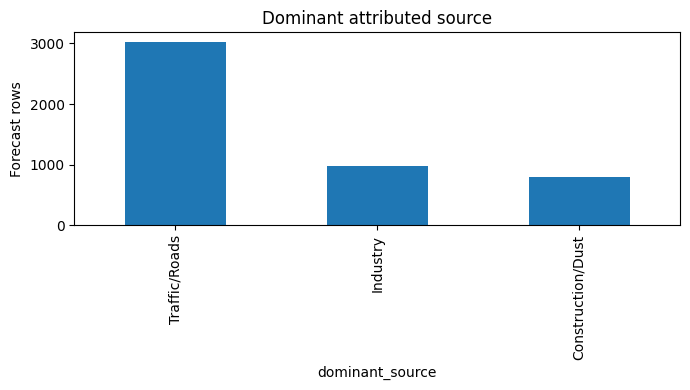

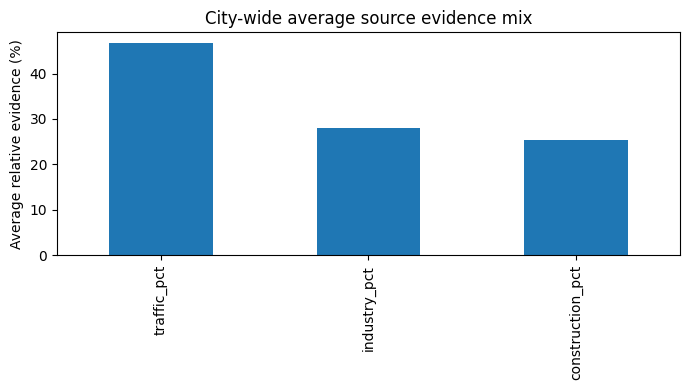

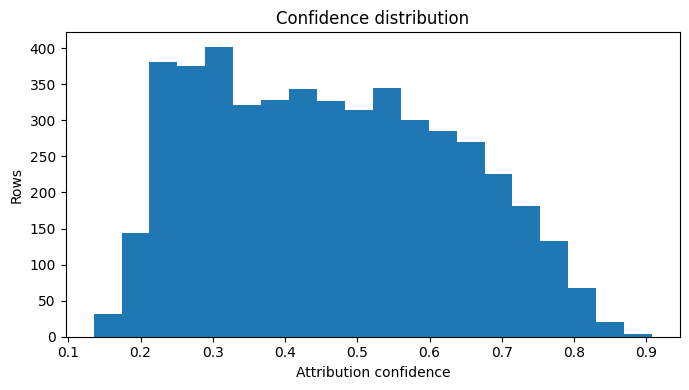

In [ ]:
import matplotlib.pyplot as plt

source_counts = result["dominant_source"].value_counts()
plt.figure(figsize=(7, 4))
source_counts.plot(kind="bar")
plt.ylabel("Forecast rows")
plt.title("Dominant attributed source")
plt.tight_layout()
plt.show()

avg_mix = result[["traffic_pct", "industry_pct", "construction_pct"]].mean()
plt.figure(figsize=(7, 4))
avg_mix.plot(kind="bar")
plt.ylabel("Average relative evidence (%)")
plt.title("City-wide average source evidence mix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(result["confidence"].dropna(), bins=20)
plt.xlabel("Attribution confidence")
plt.ylabel("Rows")
plt.title("Confidence distribution")
plt.tight_layout()
plt.show()

## 13. Optional secondary diagnostic — XGBoost + SHAP

This section is **not the primary source attribution engine**.

The earlier notebook trained a spatial model directly against `forecast_aqi` and then interpreted it with SHAP.
That can be useful to answer:

> Which static geographic features help reproduce the forecast model's spatial pattern?

But it does **not by itself establish source causality**, because the target is another model's forecast rather than labelled
source-contribution ground truth.

Use this section only as supporting model explainability.

Grouped-cell SHAP diagnostic RMSE: 30.06
Grouped-cell SHAP diagnostic R²: -0.029


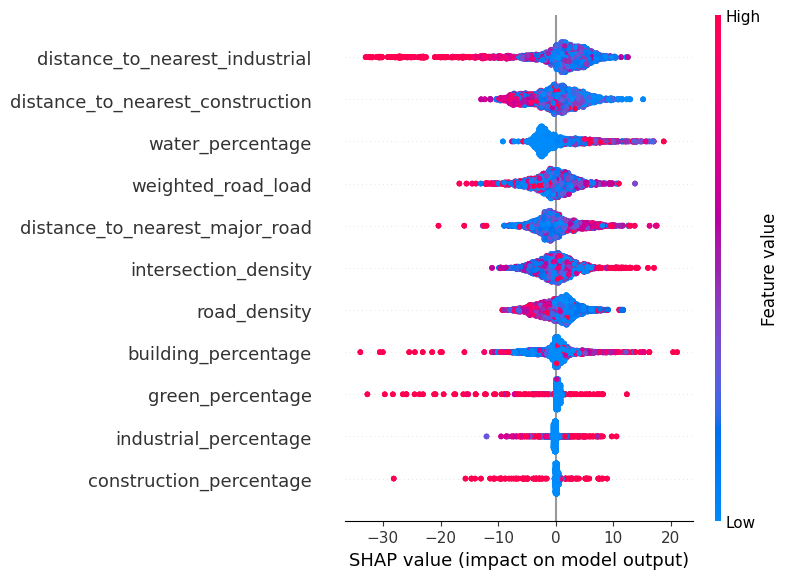

In [ ]:
RUN_SHAP_DIAGNOSTIC = True


if RUN_SHAP_DIAGNOSTIC:
    from sklearn.model_selection import GroupShuffleSplit
    from sklearn.metrics import mean_squared_error, r2_score
    from xgboost import XGBRegressor
    import shap

    spatial_cols = [
        "weighted_road_load", "road_density", "distance_to_nearest_major_road",
        "intersection_density",
        "industrial_percentage", "distance_to_nearest_industrial",
        "construction_percentage", "distance_to_nearest_construction",
        "building_percentage", "green_percentage", "water_percentage",
    ]
    spatial_cols = [c for c in spatial_cols if c in e.columns]

    diag = e.dropna(subset=["forecast_aqi"]).copy()
    X = diag[spatial_cols].replace([np.inf, -np.inf], np.nan)
    y = diag["forecast_aqi"]
    groups = diag["cell_id"]

    # Group split prevents the same physical cell appearing in both train and test
    # merely because it has different forecast horizons.
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups))

    model = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
    )
    model.fit(X.iloc[train_idx], y.iloc[train_idx])

    pred = model.predict(X.iloc[test_idx])
    rmse = mean_squared_error(y.iloc[test_idx], pred) ** 0.5
    r2 = r2_score(y.iloc[test_idx], pred)

    print(f"Grouped-cell SHAP diagnostic RMSE: {rmse:.2f}")
    print(f"Grouped-cell SHAP diagnostic R²: {r2:.3f}")

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    shap.summary_plot(shap_values, X)

## 14. What is complete after this notebook runs

### Completed
- existing OSM extraction reused;
- 1 km cell-level road/land-use features;
- traffic, industrial and construction candidate-source evidence;
- forecast-horizon wind integration;
- upwind transport corridors;
- wind-aware source scoring;
- dominant-source attribution;
- relative source distribution;
- confidence score;
- evidence text for the dashboard;
- CSV and GeoJSON outputs;
- validation summaries.

### Still a future enhancement
- active burning attribution using VIIRS/MODIS fire anomalies;
- real traffic congestion rather than OSM road-density proxy;
- construction permit feeds;
- labelled source-apportionment data for supervised calibration;
- full Gaussian plume/AERMOD dispersion modelling.

The output should be described as **directional, evidence-based source attribution**. It identifies the most plausible
source category given local geography and wind transport; it is not chemical source apportionment.

## Forecast-wind methodology

The primary attribution now uses forecast wind matched to each AQI `target_timestamp` and nearest weather-grid point.
Consequently, 24h, 48h and 72h forecasts can produce different upwind corridors. Refresh the cached spatial weather
forecast whenever a new AQI forecast run is generated.